In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import polars as pl

from backtester import samplers

In [3]:
plt.rcParams["figure.facecolor"] = "darkgray"
plt.rcParams["axes.facecolor"] = "lightgray"

In [4]:
t0 = datetime(2025, 1, 1, tzinfo=timezone.utc)
tf = datetime(2025, 12, 31, tzinfo=timezone.utc)
dt = timedelta(hours=1)

In [5]:
path_rate = samplers.get_path_rate(t0, tf, dt)
path_rate.collect()

time_start,time_end,rate
"datetime[μs, UTC]","datetime[μs, UTC]",f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,0.05
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,0.050051
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,0.050066
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,0.050152
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,0.050099
…,…,…
2025-12-30 19:00:00 UTC,2025-12-30 20:00:00 UTC,0.051246
2025-12-30 20:00:00 UTC,2025-12-30 21:00:00 UTC,0.051224
2025-12-30 21:00:00 UTC,2025-12-30 22:00:00 UTC,0.051274


In [6]:
paths_mark = samplers.get_paths_mark(t0, tf, dt)
paths_mark.collect()

time_start,time_end,name,price
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64
2025-01-01 00:00:00 UTC,2025-01-01 01:00:00 UTC,"""btc""",99966.477218
2025-01-01 01:00:00 UTC,2025-01-01 02:00:00 UTC,"""btc""",99855.58908
2025-01-01 02:00:00 UTC,2025-01-01 03:00:00 UTC,"""btc""",99814.737656
2025-01-01 03:00:00 UTC,2025-01-01 04:00:00 UTC,"""btc""",99307.943063
2025-01-01 04:00:00 UTC,2025-01-01 05:00:00 UTC,"""btc""",98689.34539
…,…,…,…
2025-12-30 19:00:00 UTC,2025-12-30 20:00:00 UTC,"""hype""",290.209662
2025-12-30 20:00:00 UTC,2025-12-30 21:00:00 UTC,"""hype""",289.449215
2025-12-30 21:00:00 UTC,2025-12-30 22:00:00 UTC,"""hype""",288.003635


<Axes: xlabel='time_end', ylabel='log price'>

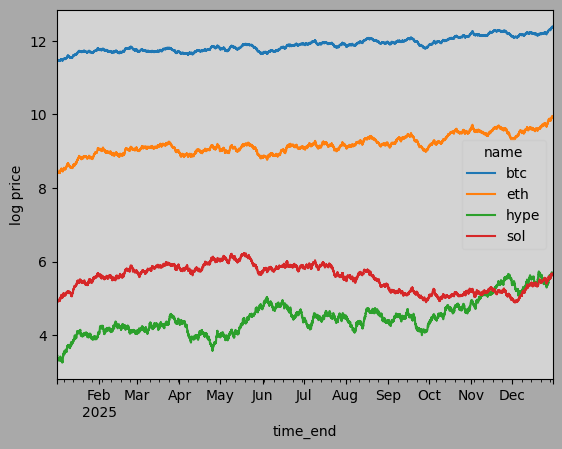

In [7]:
paths_mark \
    .with_columns(pl.col("price").log().alias("s")) \
    .collect() \
    .to_pandas() \
    .pivot_table("s", "time_end", "name") \
    .plot \
    .line(ylabel="log price")  # fmt: off

In [8]:
# # Seven daily contracts (08:00 UTC)
# daily = rrule(DAILY, byhour=8)
# # Four weekly contracts (Fridays at 08:00 UTC)
# weekly = rrule(WEEKLY, byweekday=FR, byhour=8)
# # Three monthly contracts (last Friday of each month at 08:00 UTC)
# monthly = rrule(MONTHLY, byweekday=FR(-1), byhour=8)
# # Four quarterly contracts (last Friday of Mar, Jun, Sep, Dec at 08:00 UTC)
# quarterly = rrule(MONTHLY, bymonth=(3, 6, 9, 12), byweekday=FR(-1), byhour=8)

In [9]:
bars_option = samplers.to_bars_option(paths_mark, "drbt", "btc", "usd", rules=[samplers._WEEKLY, samplers._QUARTERLY])
bars_option.collect()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2025-12-30 23:00:00 UTC,2025-12-31 00:00:00 UTC,"""drbt""","""btc""","""usd""",240000.0,2025-12-26 08:00:00 UTC,2026-03-27 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 22:00:00 UTC,2025-12-30 23:00:00 UTC,"""drbt""","""btc""","""usd""",240000.0,2025-12-26 08:00:00 UTC,2026-03-27 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 21:00:00 UTC,2025-12-30 22:00:00 UTC,"""drbt""","""btc""","""usd""",240000.0,2025-12-26 08:00:00 UTC,2026-03-27 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 20:00:00 UTC,2025-12-30 21:00:00 UTC,"""drbt""","""btc""","""usd""",240000.0,2025-12-26 08:00:00 UTC,2026-03-27 08:00:00 UTC,"""c""",0.99,1.01,1.0
2025-12-30 19:00:00 UTC,2025-12-30 20:00:00 UTC,"""drbt""","""btc""","""usd""",240000.0,2025-12-26 08:00:00 UTC,2026-03-27 08:00:00 UTC,"""c""",0.99,1.01,1.0
…,…,…,…,…,…,…,…,…,…,…,…
2025-01-03 12:00:00 UTC,2025-01-03 13:00:00 UTC,"""drbt""","""btc""","""usd""",78000.0,2025-01-03 08:00:00 UTC,2025-01-10 08:00:00 UTC,"""p""",0.99,1.01,1.0
2025-01-03 11:00:00 UTC,2025-01-03 12:00:00 UTC,"""drbt""","""btc""","""usd""",78000.0,2025-01-03 08:00:00 UTC,2025-01-10 08:00:00 UTC,"""p""",0.99,1.01,1.0
2025-01-03 10:00:00 UTC,2025-01-03 11:00:00 UTC,"""drbt""","""btc""","""usd""",78000.0,2025-01-03 08:00:00 UTC,2025-01-10 08:00:00 UTC,"""p""",0.99,1.01,1.0


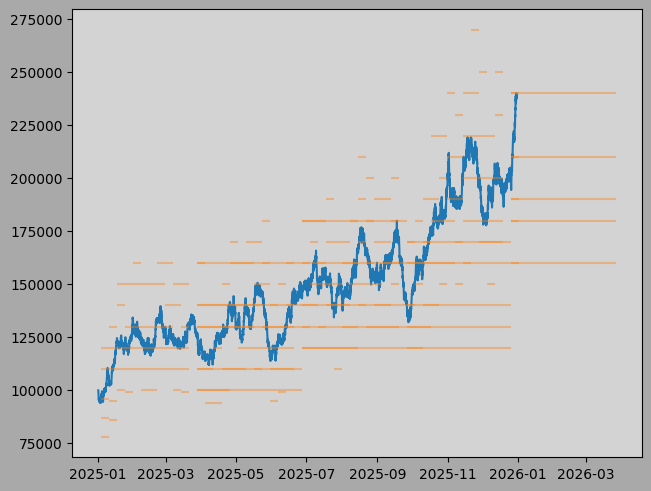

In [10]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(paths_mark.filter(pl.col("name").eq("btc")).collect()["time_end"],
        paths_mark.filter(pl.col("name").eq("btc")).collect()["price"])
for strike, listing, expiry in bars_option.select(["strike", "listing", "expiry"]).unique().collect().iter_rows():  # fmt: off
    ax.hlines(strike, listing, expiry, color="tab:orange", alpha=0.4)